In [2]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 72.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=f6626e9ed86956ad4231c815e53624cc3b908cf2a0158f5b198dee832ffd0794
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


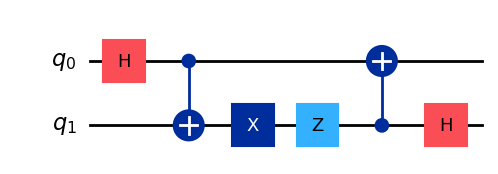

In [3]:
import numpy as np
from qiskit import QuantumCircuit

# Superdense coding

# The classical 2-bit value is encoded by applying X and/or Z gates

sdc = QuantumCircuit(2)

# qubits 0 and 1 are the shared entangled state
# Alice has qubit 1, Bob has qubit 0

# Entangle qubits 0 and 1
sdc.h(0)
sdc.cx(0,1)

# --- Encoding by Alice, working on qubit 1 ---
# Define the classical 2-bit value Alice wants to send
# You can change this value to "00", "01", "10", or "11"
classical_bits = "11" # Example: sending "11"

# Apply gates based on the classical bits
if classical_bits == "00":
    # Do nothing for "00"
    pass
elif classical_bits == "01":
    # Apply X to qubit 1 for "01"
    sdc.x(1)
elif classical_bits == "10":
    # Apply Z to qubit 1 for "10"
    sdc.z(1)
elif classical_bits == "11":
    # Apply X then Z to qubit 1 for "11"
    sdc.x(1)
    sdc.z(1)
else:
    raise ValueError("Invalid classical_bits value. Must be '00', '01', '10', or '11'.")

# --- Decoding by Bob, working on qubits 0 and 1 ---
sdc.cx(1,0)
sdc.h(1)

sdc.draw("mpl")

In [4]:
state = Statevector.from_int(0, 4)  # 4 basis states on 2 qubits

# Apply the circuit to the state
state = state.evolve(sdc)

# Display using latex.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

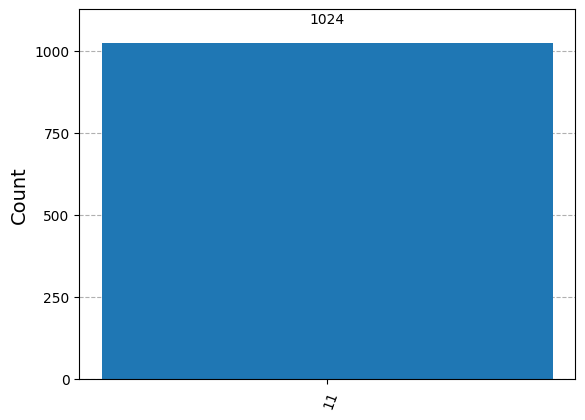

In [5]:
# Add classical bits to store measurement results
sdc.measure_all()

# Simulate the circuit
simulator = BasicSimulator()
compiled_circuit = transpile(sdc, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(compiled_circuit)

# Plot the histogram of the measurement results
plot_histogram(counts)

Superdense coding circuit for sending classical bits: '10'


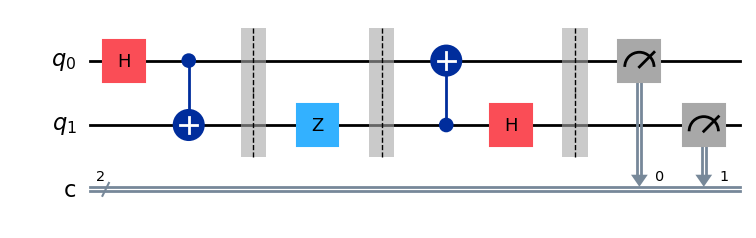


Measurement results for sending '10':


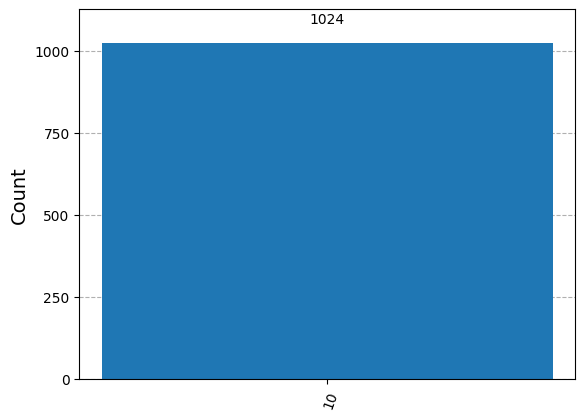

In [6]:
import numpy as np

def superdense_coding_circuit(classical_bits):

    if len(classical_bits) != 2 or not all(b in '01' for b in classical_bits):
        raise ValueError("classical_bits must be a two-character string of '0' or '1' (e.g., '00').")

    sdc = QuantumCircuit(2, 2) # 2 qubits, 2 classical bits for measurement

    # Qubits 0 and 1 are the shared entangled state
    # Alice has qubit 1, Bob has qubit 0

    # Entangle qubits 0 and 1 (create a Bell state |Phi+>)
    sdc.h(0)
    sdc.cx(0, 1)
    sdc.barrier() # Optional: add a barrier for visualization

    # Encoding by Alice, working on qubit 1
    # Alice applies gates to qubit 1 based on the classical bits she wants to send.
    # This mimics the correction stage in teleportation where X is conditioned on c0 and Z on c1.
    # Here, classical_bits[1] corresponds to the 'b0' bit, and classical_bits[0] to the 'b1' bit.
    if classical_bits[1] == '1':  # If the second bit (b0) is 1, apply X
        sdc.x(1)
    if classical_bits[0] == '1':  # If the first bit (b1) is 1, apply Z
        sdc.z(1)
    sdc.barrier()

    # Decoding by Bob, working on qubits 0 and 1
    # Bob performs the inverse of entanglement followed by measurement
    sdc.cx(1, 0)
    sdc.h(1)
    sdc.barrier()

    # Bob measures both qubits to retrieve the classical bits
    sdc.measure([0, 1], [0, 1])

    return sdc

# Example: Alice wants to send "10" (classical_bits[0]=1, classical_bits[1]=0)
# Expected outcome: '10'
classical_value_to_send = "10"
superdense_circuit = superdense_coding_circuit(classical_value_to_send)

print(f"Superdense coding circuit for sending classical bits: '{classical_value_to_send}'")
display(superdense_circuit.draw("mpl"))

# Simulate the circuit to verify
simulator = BasicSimulator()
compiled_circuit = transpile(superdense_circuit, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(compiled_circuit)

print(f"\nMeasurement results for sending '{classical_value_to_send}':")
display(plot_histogram(counts))